# Vergleich zwischen F1 und Hermes 2012

In [1]:
import sys
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from CoolProp.HumidAirProp import HAPropsSI
from CoolProp.CoolProp import PropsSI

here = Path.cwd()
repo_root = here.parents[1]
sys.path.insert(0, str(repo_root))

from Framework.runtime.recorder import ResultRecorder

from Framework.models.Frostmodell_Hermes_2012 import (
    Flatplate, AirProperty, OpPoint, HermesParams,
    X_of_s, t_of_s
)


## Case 2 (F1) laden

In [2]:
case_base = "results_case_2"
data = ResultRecorder.read_results_csv_json(str(case_base))

## Mittelwerte bestimmen

In [3]:
t = np.asarray(data["t"], dtype=float)
s_sim = np.asarray(data["mean_s_ft"], dtype=float)  # [m]
v_in = np.asarray(data["v_in_air"], dtype=float)    # [m/s]

# helpers für Spalten, die als [in,out] gespeichert sind
def _as_2col(arr, name):
    a = np.asarray(arr, dtype=float)
    if a.ndim == 1:
        # falls nur inlet gespeichert wäre
        return a.reshape(-1, 1)
    return a

humidity = _as_2col(data.get("humidity"), "humidity")
air_temp_l = _as_2col(data.get("air_temp_l"), "air_temp_l")

w_in = humidity[:, 0]       # [kg/kg]
Ta_in = air_temp_l[:, 0]    # [°C]

# --- Zeitfenster definieren ---
# ab Frostbeginn mitteln
t_avg_start = 300.0   # [s]
t_avg_end   = 3600    # bis Ende

m_avg = np.isfinite(t)
m_avg &= (t >= t_avg_start)
if t_avg_end is not None:
    m_avg &= (t <= t_avg_end)

p_a = 101325.0  # Pa
Ta = 0.0
RH = 0.8
w_in = HAPropsSI("W", "T", Ta+273.15, "P", p_a, "R", RH)
ua_mean = float(np.nanmean(v_in[m_avg]))

print("Ta [°C]:", Ta)
print("w_in_mean [kg/kg]:", w_in)
print("ua_mean [m/s]:", ua_mean)


Ta [°C]: 0.0
w_in_mean [kg/kg]: 0.003028336875167161
ua_mean [m/s]: 1.485425567837874


## T_tube mitteln

In [4]:
results = ResultRecorder.from_jsonl(str(case_base), rebuild_objects=True)
snaps = results.grid_snapshots

t_snap = np.array([float(s["t"]) for s in snaps], dtype=float)

Tw_segmean = np.zeros_like(t_snap)
for i, snap in enumerate(snaps):
    # bevorzugt cfg_grid (da T_tube bei dir in cfg liegt)
    if "cfg_grid" in snap:
        grid = snap["cfg_grid"]
        vals = []
        for ix in range(len(grid)):
            for iy in range(len(grid[0])):
                vals.append(float(getattr(grid[ix][iy], "T_tube")))
        Tw_segmean[i] = float(np.mean(vals))
    else:
        # Fallback: st_grid (falls du T_tube dort ablegst)
        grid = snap["st_grid"]
        vals = []
        for ix in range(len(grid)):
            for iy in range(len(grid[0])):
                vals.append(float(getattr(grid[ix][iy], "T_tube")))
        Tw_segmean[i] = float(np.mean(vals))

m_avg_snap = np.isfinite(t_snap) & (t_snap >= t_avg_start)
if t_avg_end is not None:
    m_avg_snap &= (t_snap <= t_avg_end)

Tw_mean = float(np.nanmean(Tw_segmean[m_avg_snap]))

print("Tw_mean [°C]:", Tw_mean)

Tw_mean [°C]: -8.44048966296203


## Berechnen der analytischen Hermes Kurve

In [5]:
# w_w: Sättigungsfeuchte bei Wandtemperatur
w_w = float(HAPropsSI("W", "T", Tw_mean + 273.15, "P", p_a, "R", 1.0))
w_tilde = w_in - w_w

# RH aus (T, w)
RH_mean = float(HAPropsSI("R", "T", Ta + 273.15, "P", p_a, "W", w_in))

# Luftstoffwerte am mittleren Betriebspunkt
k_a = float(HAPropsSI("K",  "T", Ta + 273.15, "P", p_a, "R", RH_mean))
c_p = float(HAPropsSI("cp", "T", Ta + 273.15, "P", p_a, "R", RH_mean))
mu  = float(HAPropsSI("M",  "T", Ta + 273.15, "P", p_a, "R", RH_mean))
rho = float(PropsSI("D", "T", Ta + 273.15, "P", p_a, "Air"))

air = AirProperty(k_a=k_a, c_p=c_p, rho=rho, mu=mu)
op  = OpPoint(T_a=Ta, T_w=Tw_mean, w_tilde=w_tilde, u_a=ua_mean)

# Hermes-Parameter (wie in deinem Script)
hp = HermesParams(
    a0=207.3,
    a1=0.266,
    a2=(-0.0615) * Tw_mean,
    k_f0=0.132,
    i_sv=2830000.0,
    beta=0.000313
)

# L: charakteristische Länge
L = 0.1
geom_hp = Flatplate(L=L)

def hermes_delta_at_times(t_query_s, *, s_end_init=6.0, N=4000):
    """
    Liefert delta(t) [m] für gegebene Zeiten (Sekunden) via (s -> t(s), X(s)) -> Interpolation.
    """
    t_query_s = np.asarray(t_query_s, dtype=float)

    # s_end so wählen, dass t_of_s(s_end) >= max(t_query)
    t_max = float(np.nanmax(t_query_s))
    s_end = float(s_end_init)
    for _ in range(25):
        t_end_est = float(t_of_s(s_end, geom_hp, air, op, hp))
        if np.isfinite(t_end_est) and t_end_est >= t_max:
            break
        s_end *= 1.6
    else:
        raise RuntimeError("s_end konnte nicht so erweitert werden, dass t_of_s(s_end) groß genug ist.")

    s_arr = np.linspace(1e-9, s_end, N)
    t_arr = np.array([float(t_of_s(sv, geom_hp, air, op, hp)) for sv in s_arr], dtype=float)
    X_arr = np.array([float(X_of_s(sv, geom_hp, air, op, hp)) for sv in s_arr], dtype=float)

    m = np.isfinite(t_arr) & np.isfinite(X_arr) & (t_arr > 0)
    t_arr = t_arr[m]
    X_arr = X_arr[m]
    order = np.argsort(t_arr)
    t_arr = t_arr[order]
    X_arr = X_arr[order]

    delta_arr = X_arr * L  # [m]
    return np.interp(t_query_s, t_arr, delta_arr, left=delta_arr[0], right=delta_arr[-1])

# --- Vergleichszeitfenster ---
t_plot_start = 0.0
t_plot_end   = None

m_plot = np.isfinite(t)
m_plot &= (t >= t_plot_start)
if t_plot_end is not None:
    m_plot &= (t <= t_plot_end)

t_plot = t[m_plot]
s_plot = s_sim[m_plot]

# Optionaler Shift: Hermes startet bei Frostbeginn (z.B. 300 s)
t_frost_start = 300.0
t_eff = np.clip(t_plot - t_frost_start, 0.0, None)

delta_hermes = hermes_delta_at_times(t_eff)
delta_hermes[t_plot < t_frost_start] = 0.0  # vor Frostbeginn: 0

## Vergleich plotten und speichern

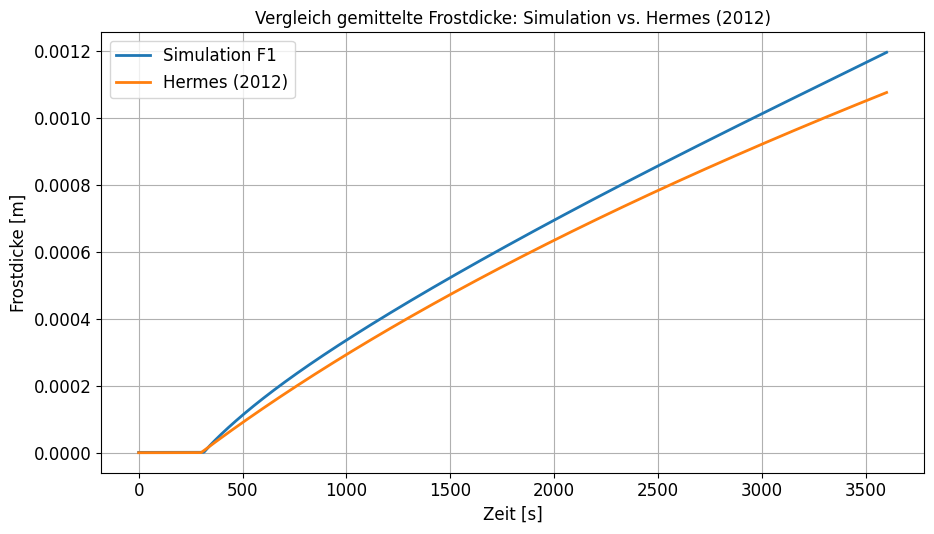

In [12]:
def plot_mean_frost_compare(t_s, s_sim_m, s_hermes_m, *,
                            title=None, save_path=None, y_unit="m"):
    t_s = np.asarray(t_s, dtype=float)
    s_sim_m = np.asarray(s_sim_m, dtype=float)
    s_hermes_m = np.asarray(s_hermes_m, dtype=float)

    if y_unit.lower() == "mm":
        fac, ylab = 1e3, "Frostdicke [mm]"
    else:
        fac, ylab = 1.0, "Frostdicke [m]"

    fig, ax = plt.subplots(figsize=(9.5, 5.5))
    ax.plot(t_s, s_sim_m*fac, lw=2.0, label="Simulation F1")
    ax.plot(t_s, s_hermes_m*fac, lw=2.0, label="Hermes (2012)")

    ax.set_xlabel("Zeit [s]")
    ax.set_ylabel(ylab)
    ax.grid(True)#, alpha=0.3)
    ax.legend()

    if title is None:
        ax.set_title("Vergleich gemittelte Frostdicke: Simulation vs. Hermes (2012)")
    else:
        ax.set_title(title)

    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=600, bbox_inches="tight")
    return fig, ax

with plt.rc_context({
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
}):
    fig, ax = plot_mean_frost_compare(
        t_plot, s_plot, delta_hermes,
        save_path="Plots/mean_frost_vs_hermes.png",
        y_unit="m"
    )
    plt.show()